<a href="https://colab.research.google.com/github/kithhooni-commits/ds-practice/blob/main/%EC%8B%A4%EC%8A%B55/colab_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습5 — 반도체 이미지 denoising (Colab / A100)

배포된 `train_denoising_example.ipynb` 와 **같은 데이터 · 같은 노이즈 합성 · 같은 지표**를 쓰고
학습 쪽만 손본 파이프라인이다. 코드는 노트북에 박아 넣지 않고
[ds-practice](https://github.com/kithhooni-commits/ds-practice) 저장소의 `실습5/src/denoise/` 를 clone 해서 쓴다.
(로컬에서 돌린 것과 완전히 같은 코드라는 뜻이다.)

바꾼 것과 이유는 `실습5/README.md` 에 정리돼 있다. 요약하면:
median 채널 추가 · Charbonnier loss · cosine LR · 긴 학습 · rot90 증강 · 8× self-ensemble.

**실행 순서**: 런타임을 A100 으로 바꾸고 위에서부터 순서대로.

## 0. 런타임 확인

In [11]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())

name, memory.total [MiB]
NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB
torch 2.11.0+cu128 | cuda True


## 1. Drive 마운트

In [12]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 데이터 준비

Drive 에 **zip 그대로 올려 뒀어도 된다.** 아래 셀이 알아서 찾아 `/content/data` 로 푼다.

Colab 에서 Drive I/O 는 학습의 병목이라, 어차피 로컬 SSD 로 옮기는 게 맞다.
zip 을 로컬로 푸는 건 Drive 폴더를 통째로 복사하는 것보다 빠르다 (파일 7,568개 vs 압축파일 1개).

이미 풀린 폴더가 Drive 에 있으면 그것도 찾는다. 배포 zip 의
`test_noise_only/test_noise_only/` 같은 중첩 구조도 그대로 받는다.

In [13]:
import os
import zipfile
from pathlib import Path

SEARCH_ROOT = Path("/content/drive/MyDrive")   # zip 또는 dataset 폴더가 있는 곳
WORK = Path("/content/data")                   # 여기로 푼다 (로컬 SSD)
DATA_ROOT = None                               # 직접 지정하려면 여기에 경로를 적는다

WANT = ("dataset", "log_denoising_example", "code_denoising")


def looks_like_dataset(p: Path) -> bool:
    return (p / "train").is_dir() and (p / "test_label").is_dir()


def find_dataset(root: Path) -> list[Path]:
    seen = [root] + [p for d in ("*", "*/*", "*/*/*") for p in root.glob(d) if p.is_dir()]
    return [p for p in seen if looks_like_dataset(p)]


WORK.mkdir(parents=True, exist_ok=True)

# 1) Drive 에 zip 으로 올려 뒀으면 로컬 SSD 로 푼다
zips = [z for d in ("*.zip", "*/*.zip") for z in SEARCH_ROOT.glob(d)]
for z in sorted(zips):
    tag = next((w for w in WANT if z.name.startswith(w)), None)
    if tag is None:
        continue
    if (WORK / tag).exists():
        print("이미 있음:", WORK / tag)
        continue
    print("푸는 중:", z.name, "->", WORK)
    with zipfile.ZipFile(z) as f:
        f.extractall(WORK)

# 2) dataset 폴더 위치 확정 — 로컬에 푼 것 우선, 없으면 Drive 에서 찾는다
if DATA_ROOT is None:
    cands = find_dataset(WORK) or find_dataset(SEARCH_ROOT)
    if not cands:
        print("MyDrive 안:", [x.name for x in list(SEARCH_ROOT.iterdir())[:30]])
        print("WORK 안  :", [x.name for x in list(WORK.iterdir())[:30]])
        raise SystemExit("dataset 을 못 찾았다. zip 이름이나 위치를 확인하고 DATA_ROOT 를 직접 적을 것")
    DATA_ROOT = cands[0]
    if len(cands) > 1:
        print("후보가 여럿이다. 첫 번째를 쓴다:", [str(c) for c in cands])

DATA_ROOT = Path(DATA_ROOT)
os.environ["DS_DATA"] = str(DATA_ROOT)
print()
print("DATA_ROOT =", DATA_ROOT)
for sub in ("train", "val", "test_label", "test_noise_only"):
    q = DATA_ROOT / sub
    n = len(list(q.glob("**/*.npy"))) if q.exists() else 0
    print(f"{'OK  ' if n else '없음'} {sub:<18} {n:>5} npy")

이미 있음: /content/data/code_denoising
이미 있음: /content/data/dataset
이미 있음: /content/data/log_denoising_example

DATA_ROOT = /content/data/dataset
OK   train               7268 npy
OK   val                  100 npy
OK   test_label           100 npy
OK   test_noise_only      100 npy


### dataset 이 아직 Drive 에 있으면 로컬로 복사

위 셀이 Drive 에 이미 풀려 있던 폴더를 골랐다면, 학습 내내 Drive 에서 파일을 읽게 된다.
그건 느리다. 아래 셀이 그 경우에만 로컬로 옮긴다. (이미 `/content` 면 아무것도 안 한다.)

In [14]:
import shutil

if str(DATA_ROOT).startswith("/content/drive"):
    dest = WORK / "dataset"
    if not dest.exists():
        print("복사 중:", DATA_ROOT, "->", dest)
        shutil.copytree(DATA_ROOT, dest)
    DATA_ROOT = dest
    os.environ["DS_DATA"] = str(DATA_ROOT)

print("DATA_ROOT =", DATA_ROOT)
!du -sh "{DATA_ROOT}"

DATA_ROOT = /content/data/dataset
1.9G	/content/data/dataset


## 3. 코드 받기

In [48]:
REPO = Path("/content/ds-practice")
if REPO.exists():
    !cd "{REPO}" && git pull --ff-only
else:
    !git clone --depth 1 https://github.com/kithhooni-commits/ds-practice.git "{REPO}"

SRC = REPO / "실습5" / "src" / "denoise"
RUNS = Path("/content/runs")
RUNS.mkdir(exist_ok=True)


def find_ckpt(tag: str = ""):
    """학습 결과 체크포인트를 찾는다. tag 가 이름에 든 것을 우선하고, 없으면 가장 최근 것.

    Colab 런타임이 재시작되면 /content 는 비므로, Drive 백업 폴더도 같이 뒤진다.
    """
    roots = [RUNS, Path("/content/drive/MyDrive/실습프로젝트/runs_mine")]
    found = []
    for root in roots:
        if root.exists():
            found += list(root.glob("*/checkpoints/checkpoint_best.ckpt"))
    if not found:
        for root in roots:
            names = [p.name for p in root.iterdir()] if root.exists() else "(폴더 없음)"
            print(f"{root} -> {names}")
        raise SystemExit(
            "체크포인트가 없다. 위의 학습 셀을 먼저 돌리거나, "
            "CKPT = Path(\"...\") 로 직접 지정할 것."
        )
    hit = [p for p in found if tag in p.parent.parent.name] if tag else []
    pick = max(hit or found, key=lambda p: p.stat().st_mtime)
    if len(found) > 1:
        print("찾은 체크포인트:")
        for p in sorted(found, key=lambda q: q.stat().st_mtime):
            print(("  * " if p == pick else "    ") + p.parent.parent.name)
    return pick


!ls "{SRC}"

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 1.73 KiB | 1.73 MiB/s, done.
From https://github.com/kithhooni-commits/ds-practice
   fb37367..b774994  main       -> origin/main
Updating fb37367..b774994
Fast-forward
 "\354\213\244\354\212\2655/README.md"              | 37 +++++++++++++++-------
 .../src/denoise/make_ppt.py"                       |  1 +
 2 files changed, 27 insertions(+), 11 deletions(-)
analyze_gate.py     filters.py	     metrics.py		  train_n2v.py
check_baselines.py  make_figures.py  models.py		  train.py
data.py		    make_ppt.py      __pycache__
evaluate.py	    make_preview.py  report_per_image.py


## 4. 지표 검증 — 먼저 여기부터

우리가 재는 PSNR/SSIM 이 채점 숫자와 같은지 확인한다. 배포된 예시 로그
(`log_denoising_example/00012_train/baseline_metrics.json`)의 mean/median/adaptive 성적을
우리 로더·우리 지표로 다시 재서 대조한다.

**`PSNR 최대 차이: 0.0000 dB — 일치` 가 나와야 다음으로 넘어간다.**
여기가 어긋나면 학습 결과도 믿을 수 없다.

(예시 로그를 Drive 에 안 올렸으면 대조 없이 우리 숫자만 나온다. 그래도 상관없다.)

In [16]:
LOG_EXAMPLE = next(
    (p for p in (WORK / "log_denoising_example", SEARCH_ROOT / "log_denoising_example") if p.exists()),
    None,
)
if LOG_EXAMPLE is None:
    hits = [p for d in ("*/log_denoising_example", "*/*/log_denoising_example") for p in SEARCH_ROOT.glob(d)]
    LOG_EXAMPLE = hits[0] if hits else None

DEST = REPO / "실습5" / "data"
if LOG_EXAMPLE is not None and not (DEST / "log_denoising_example").exists():
    DEST.mkdir(parents=True, exist_ok=True)
    !cp -r "{LOG_EXAMPLE}" "{DEST}/"

print("예시 로그:", LOG_EXAMPLE or "없음 (대조 없이 우리 숫자만 나온다)")

!cd "{SRC}" && python check_baselines.py --data "{DATA_ROOT}"

예시 로그: /content/data/log_denoising_example
data root: /content/data/dataset

[PSNR]  ours / 제공 예시 로그
noise                n                 noisy                  mean                median              adaptive
--------------------------------------------------------------------------------------------------------------
gaussian            25       27.668 / 27.668       26.316 / 26.316       27.382 / 27.382       30.078 / 30.078
rician              25       24.079 / 24.079       23.669 / 23.669       24.080 / 24.080       27.046 / 27.046
uniform             25       29.631 / 29.631       26.263 / 26.263       26.779 / 26.779       30.521 / 30.521
salt_and_pepper     25       17.304 / 17.304       23.196 / 23.196       28.496 / 28.496       21.164 / 21.164
ALL                100       24.671 / 24.671       24.861 / 24.861       26.684 / 26.684       27.202 / 27.202

[SSIM]  ours / 제공 예시 로그
noise                n                 noisy                  mean                median         

## 5. 학습

**로컬 실험에서 배운 것을 반영한 설정이다.** 처음 이 노트북은 A100 이니
`--patch 256 --batch 32` 를 권했는데, 실제로 돌려 보니 그게 더 나빴다.

- **step 수가 오히려 줄어든다.** 배치를 2배로 키우면 epoch 당 iteration 이 절반이 된다.
  7268/32 x 60ep = 13,620 step vs 7268/16 x 40ep = 18,160 step.
- **랜덤 크롭 자체가 증강이다.** patch 256 은 이미지 전체라 크롭이 없고 매 epoch 같은 그림을 본다.
- **크기를 맞출 이유가 없다.** 완전 합성곱 신경망이라 학습 패치와 추론 크기가 달라도 된다.

A100 의 이득은 배치를 키우는 게 아니라 **같은 설정으로 step 을 더 많이** 도는 데서 나온다.

### 어떤 구조를 쓸 것인가

| 모델 | 파라미터 | 수용영역 | 비고 |
|---|---|---|---|
| `dncnn` | 0.59M | 35px | 배포된 구조. 로컬 40ep 로 **34.13 / 0.9445** |
| `dncnn_plus` | 0.59M | 35px | median 채널 추가 — **손해였다** (33.75) |
| `drunet` | 32.6M | ~180px | U-Net + res block. 3일차 plug-and-play 프라이어 |

DnCNN 의 한계는 수용영역이다. 17층 3x3 은 35픽셀밖에 못 본다. DRUNet 은 3번
다운샘플해서 같은 깊이로 훨씬 넓게 본다. 그리고 이 구조는 DPIR 의 디노이저
프라이어로 설계된 것이라, **3일차 deconvolution + denoising 결합에서 그대로 재사용**된다.

A100 이면 DRUNet 을 쓰는 게 맞다. 6GB GPU 에서는 patch128/batch16 에 729 ms/iter 라
40 epoch 에 3.7시간이 걸린다.

In [33]:
!cd "{SRC}" && python train.py \
    --model drunet \
    --features 64 \
    --epochs 60 \
    --patch 128 \
    --batch 16 \
    --lr 2e-4 \
    --loss charbonnier \
    --workers 8 \
    --data "{DATA_ROOT}" \
    --out "{RUNS}" \
    --tag a100

run     : /content/runs/0831-0527_drunet_a100
device  : cuda  model: drunet  params: 32,638,080
train   : 7268 images, patch 128, batch 16 -> 454 iters/epoch
valid   : 100 images (파일명 고정 seed 노이즈)
loss    : charbonnier   lr: 0.0002 (cosine)   amp: True

  ep 00 it    0/454 loss 0.11636
  ep 00 it  100/454 loss 0.04742
  ep 00 it  200/454 loss 0.03979
  ep 00 it  300/454 loss 0.03642
  ep 00 it  400/454 loss 0.03396
[ep 00] loss 0.03300  val PSNR 29.228  SSIM 0.8031  lr 2.00e-04  12s  <- best
  ep 01 it    0/454 loss 0.02538
  ep 01 it  100/454 loss 0.02582
  ep 01 it  200/454 loss 0.02527
  ep 01 it  300/454 loss 0.02498
  ep 01 it  400/454 loss 0.02481
[ep 01] loss 0.02466  val PSNR 30.267  SSIM 0.8304  lr 1.99e-04  12s  <- best
  ep 02 it    0/454 loss 0.02151
  ep 02 it  100/454 loss 0.02276
  ep 02 it  200/454 loss 0.02324
  ep 02 it  300/454 loss 0.02316
  ep 02 it  400/454 loss 0.02292
[ep 02] loss 0.02285  val PSNR 30.138  SSIM 0.8197  lr 1.99e-04  12s
  ep 03 it    0/454 loss 0

### 비교군 — 배포 구조 그대로 (DnCNN)

DRUNet 이 실제로 더 나은지 보려면 같은 레시피로 DnCNN 을 돌려 비교해야 한다.
로컬에서 이 설정(40 epoch)으로 **34.13 / 0.9445** 가 나왔다.

그리고 median 3x3 을 두 번째 입력 채널로 주는 가설(`dncnn_plus`)은 **기각됐다.**
s&p 입력이 17.3 dB 로 혼자 낮고 고전 필터 중 median 만 통하니 도움이 될 것이라 봤는데,
정작 **s&p 구간에서 1.21 dB 를 잃었다** (35.95 -> 34.74). median 이 임펄스를 지우면서
미세 계조도 뭉개고, 네트워크가 그 뭉개진 채널에 일부 의존하게 된 것으로 보인다.
17층 3x3 이면 임펄스는 스스로 처리할 수 있었다.

In [18]:
!cd "{SRC}" && python train.py \
    --model dncnn --epochs 60 --patch 128 --batch 16 --lr 2e-4 --loss charbonnier --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag a100_dncnn

run     : /content/runs/0831-0500_dncnn_a100_dncnn
device  : cuda  model: dncnn  params: 593,024
train   : 7268 images, patch 128, batch 16 -> 454 iters/epoch
valid   : 100 images (파일명 고정 seed 노이즈)
loss    : charbonnier   lr: 0.0002 (cosine)   amp: True

  ep 00 it    0/454 loss 0.10930
  ep 00 it  100/454 loss 0.05429
  ep 00 it  200/454 loss 0.05013
  ep 00 it  300/454 loss 0.04593
  ep 00 it  400/454 loss 0.04285
[ep 00] loss 0.04171  val PSNR 27.566  SSIM 0.7528  lr 2.00e-04  10s  <- best
  ep 01 it    0/454 loss 0.03168
  ep 01 it  100/454 loss 0.03260
  ep 01 it  200/454 loss 0.03243
  ep 01 it  300/454 loss 0.03238
  ep 01 it  400/454 loss 0.03197
[ep 01] loss 0.03161  val PSNR 29.183  SSIM 0.7947  lr 1.99e-04  10s  <- best
  ep 02 it    0/454 loss 0.02985
  ep 02 it  100/454 loss 0.02791
  ep 02 it  200/454 loss 0.02769
  ep 02 it  300/454 loss 0.02728
  ep 02 it  400/454 loss 0.02725
[ep 02] loss 0.02711  val PSNR 28.382  SSIM 0.7754  lr 1.99e-04  10s
  ep 03 it    0/454 loss 

## 6. 평가 — 제출값 산출

`test_noise_only` 를 입력으로 넣고 `test_label` 로 채점한다. conventional 비교군
(mean / median / adaptive)도 같은 데이터로 함께 재서 표로 낸다.

`--self-ensemble` 은 dihedral 8종으로 추론해 되돌려 평균내는 것이다. 학습 비용 0,
추론만 8배 느려지고(100장이라 몇 초), 로컬에서 **+0.30 dB** 를 줬다.

In [34]:
# 학습 셀에서 --tag a100 을 줬으므로 그 이름을 우선한다
CKPT = find_ckpt("a100")
print("checkpoint:", CKPT)

# self-ensemble 없이 / 있게 각각 재서 그 차이도 발표 근거로 남긴다
!cd "{SRC}" && python evaluate.py "{CKPT}" --data "{DATA_ROOT}" --figures
print("=" * 70)
!cd "{SRC}" && python evaluate.py "{CKPT}" --data "{DATA_ROOT}" --self-ensemble --figures

찾은 체크포인트:
    0831-0202_dncnn_plus_a100
    0831-0442_dncnn_a100_dncnn
    0831-0500_dncnn_a100_dncnn
    0831-0500_dncnn_a100_dncnn
  * 0831-0527_drunet_a100
checkpoint: /content/runs/0831-0527_drunet_a100/checkpoints/checkpoint_best.ckpt

[PSNR]  ckpt: checkpoint_best.ckpt  self-ensemble: False
noise                n       noisy       model        mean      median    adaptive
----------------------------------------------------------------------------------
gaussian            25      27.668      35.568      26.316      27.382      30.078
rician              25      24.079      31.791      23.669      24.080      27.046
uniform             25      29.631      35.581      26.263      26.779      30.521
salt_and_pepper     25      17.304      42.032      23.196      28.496      21.164
ALL                100      24.671      36.243      24.861      26.684      27.202

[SSIM]  ckpt: checkpoint_best.ckpt  self-ensemble: False
noise                n       noisy       model        mean     

### 노이즈 종류별 before/after

test_grid.png


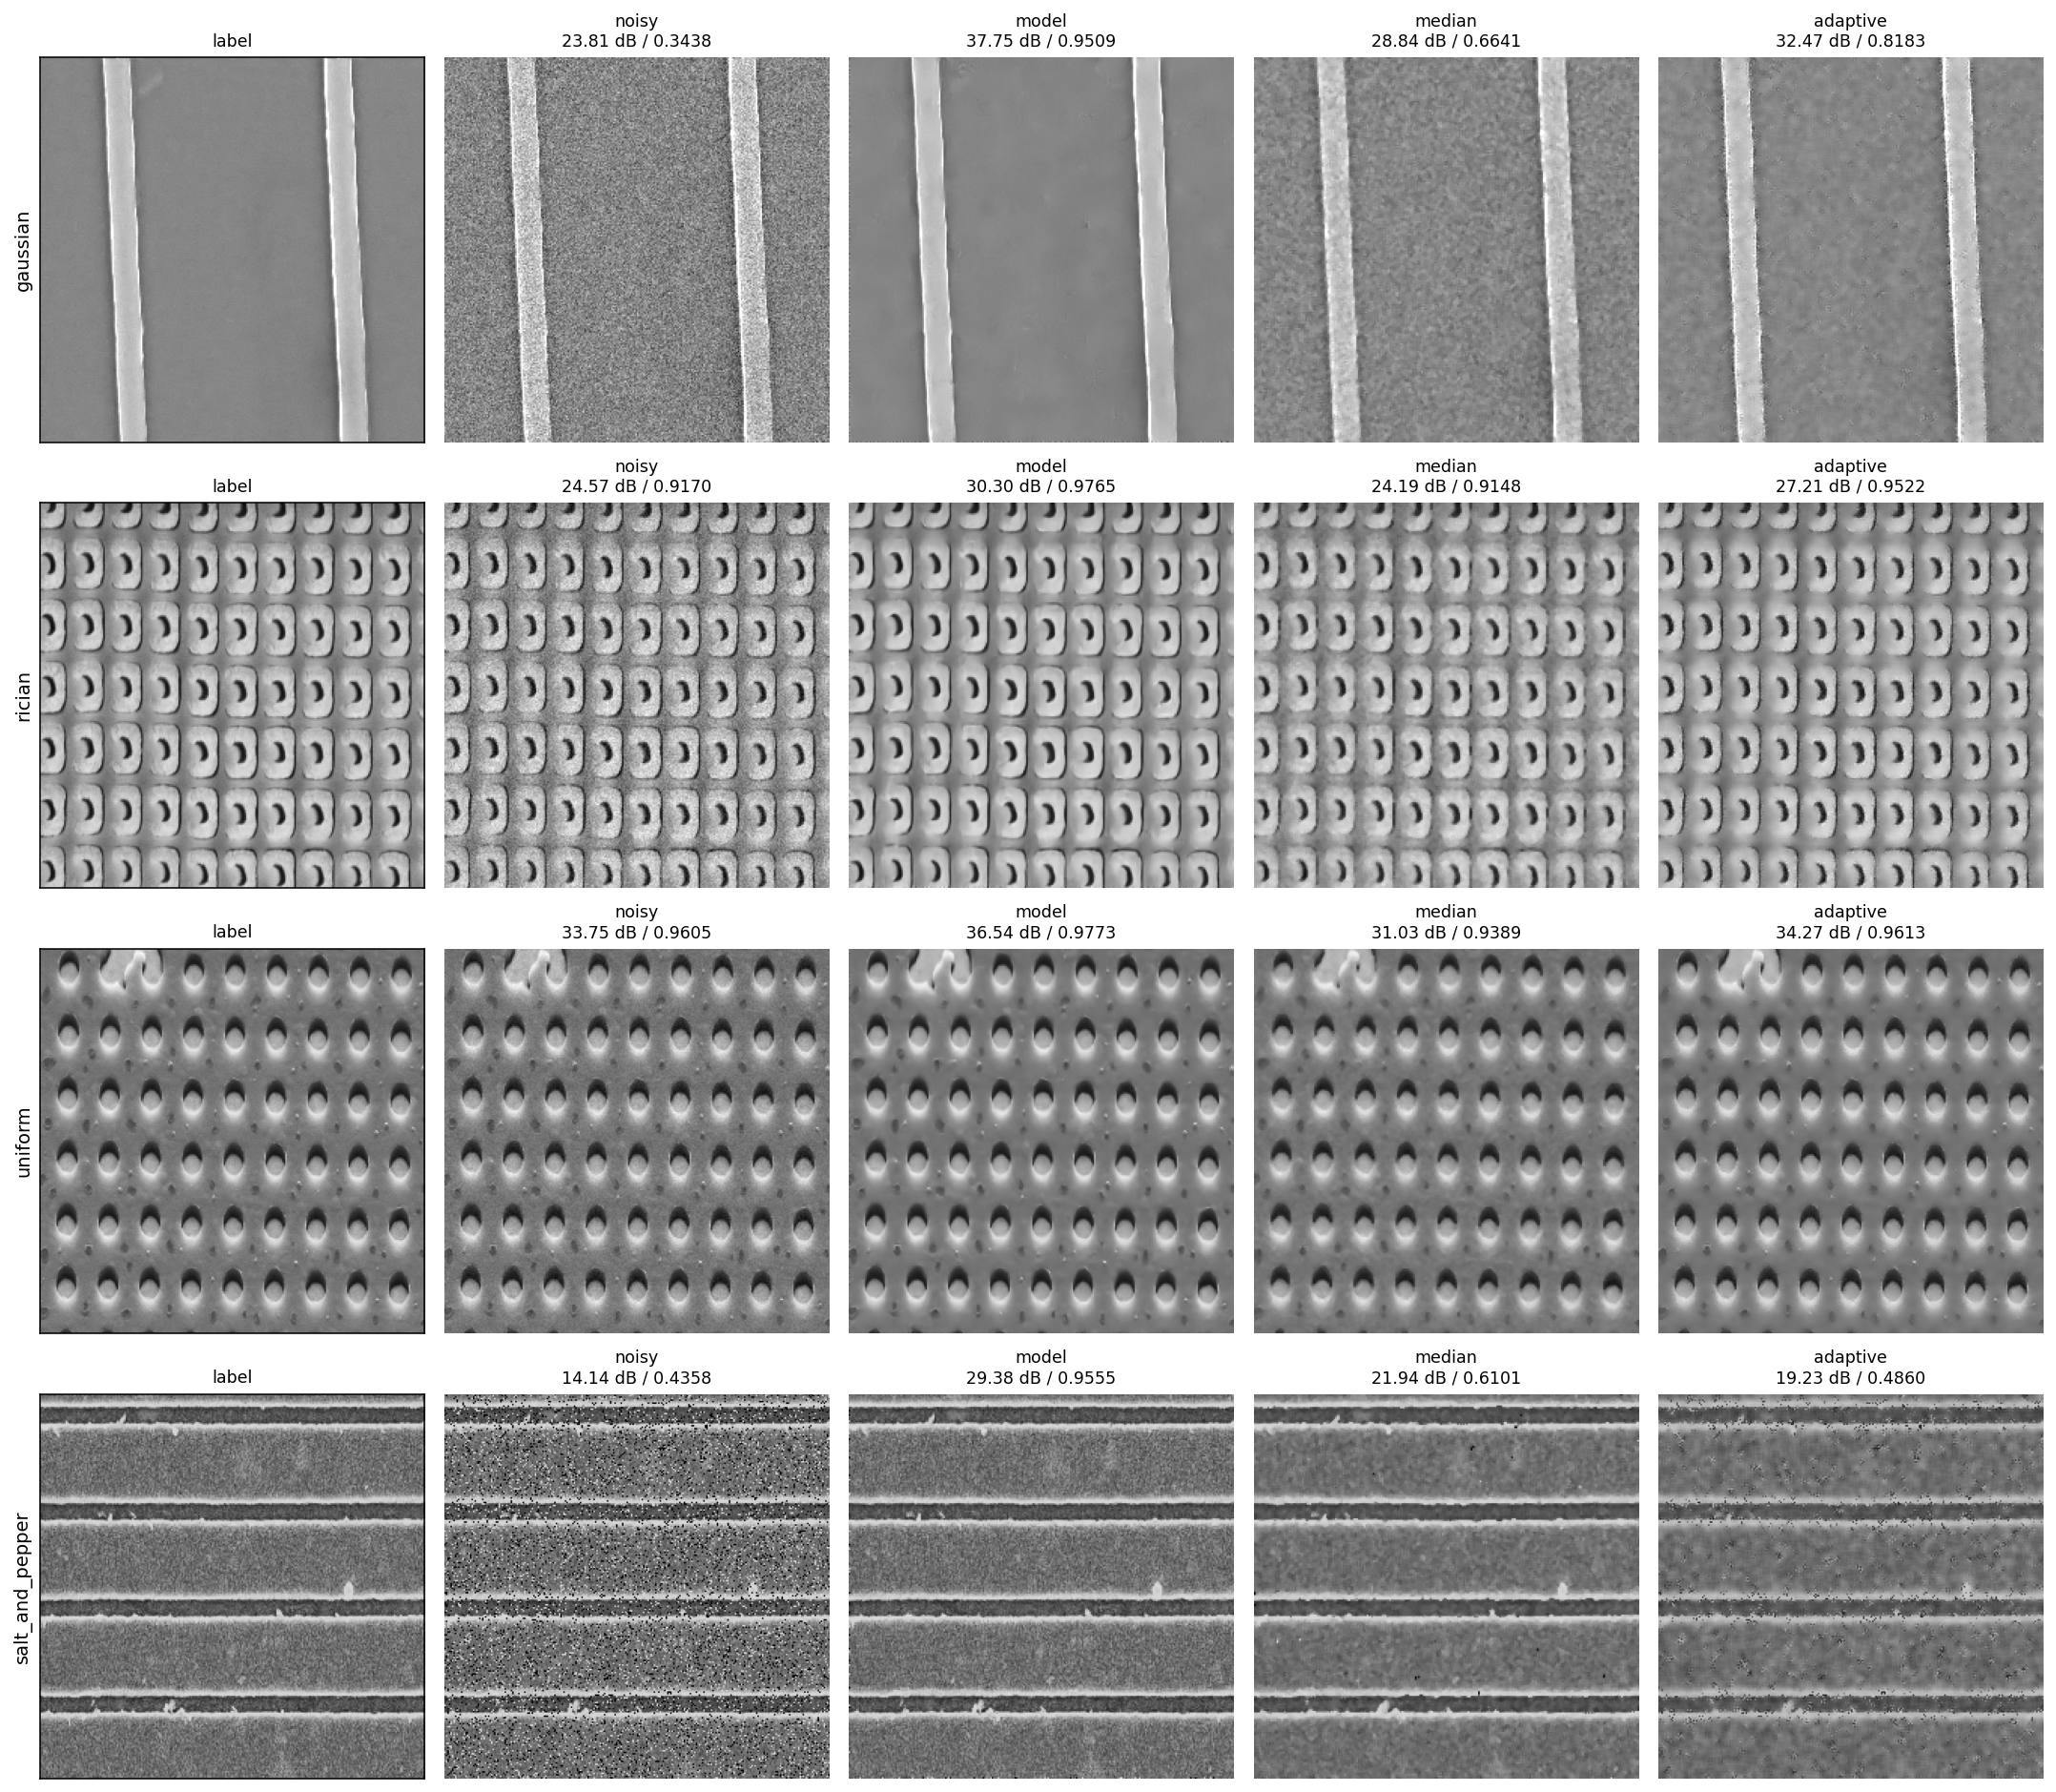

test_grid_se.png


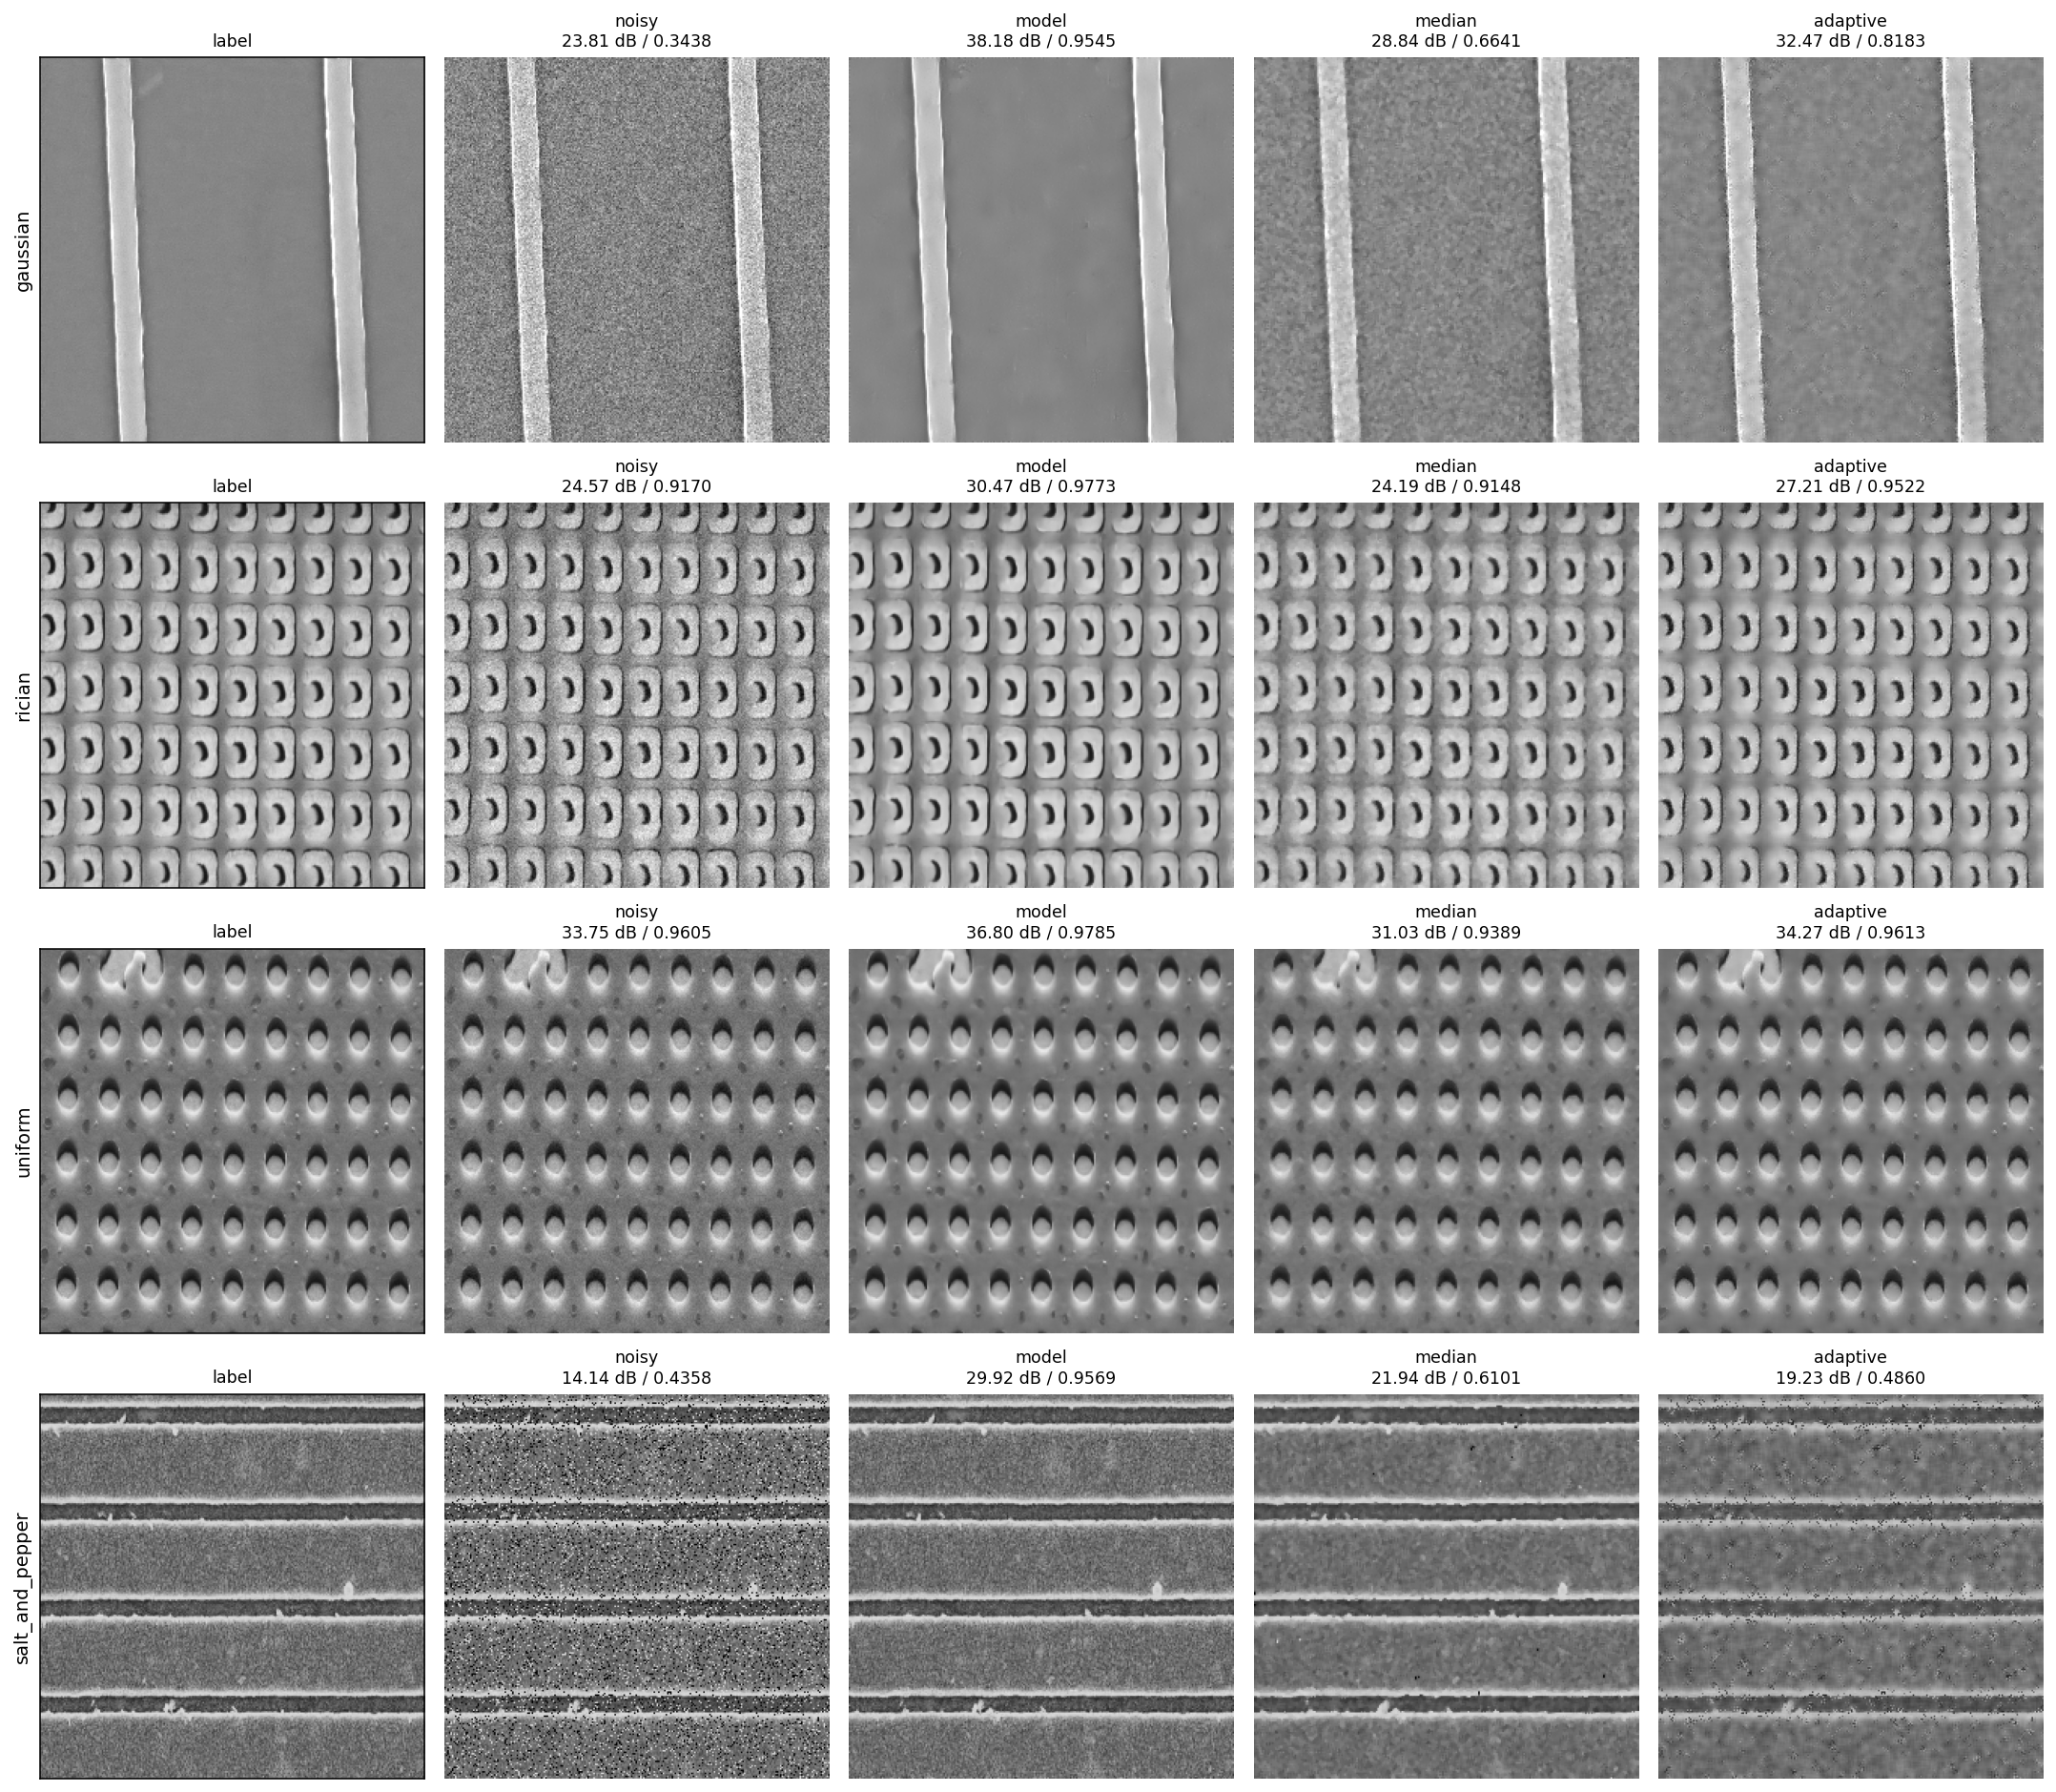

In [20]:
from IPython.display import Image, display
for p in sorted(CKPT.parent.parent.glob("test_grid*.png")):
    print(p.name)
    display(Image(filename=str(p)))

## 7. Label-free 파이프라인 (가산점)

clean 이미지를 loss 에 **한 번도 쓰지 않고** 학습한다 (Noise2Void).

어떤 픽셀의 값을 주변 값으로 덮어써 입력에서 지운 다음, 그 자리를 맞히게 한다.
정답으로는 덮어쓰기 전의 **noisy 값**을 준다. 노이즈가 픽셀마다 독립이면 주변에서
그 픽셀의 노이즈를 알아낼 방법이 없으니, 네트워크가 맞힐 수 있는 건 구조뿐이다.

우리 노이즈 4종은 전부 픽셀 독립이라 전제를 만족한다. 다만 L2 loss 는 조건부 평균을
학습하므로 노이즈 평균이 0 이어야 하는데 **s&p 와 rician 은 아니다.** 그래서 L1 을 쓴다 —
조건부 중앙값은 임펄스에 끌려가지 않는다.

**체크포인트 선택도 label-free 로 한다.** val noisy 의 마스킹 loss 로 고른다.
clean 기반 PSNR 로 고르면 파이프라인이 label-free 가 아니게 되기 때문이다.

로컬 결과: `--source test` 로 **PSNR 30.08 / SSIM 0.8882** — clean 을 한 장도 안 쓰고
배포 기준선(clean 7,268장 supervised, 30.51 / 0.8950)에 0.43 dB 까지 붙었다.

> `--source train` (train clean 으로 noisy 를 합성해 그 noisy 만 학습) 도 해 봤지만
> step 2000 이 최고점이고 그 뒤로 하락했다 (진단 PSNR 25.9). 데이터가 73배 많은데 3 dB 나쁘다.
> 평가 대상 100장에 적응하는 쪽이 일반 디노이저를 배우는 것보다 유리했다.

In [21]:
# clean 을 한 장도 건드리지 않는 학습. test_noise_only 100장만 쓴다.
!cd "{SRC}" && python train_n2v.py \
    --source test \
    --model drunet --features 64 \
    --steps 20000 \
    --patch 128 \
    --batch 16 \
    --loss l1 \
    --workers 8 \
    --data "{DATA_ROOT}" \
    --out "{RUNS}" \
    --tag lf

usage: train_n2v.py [-h] [--source {test,train}] [--model {dncnn,dncnn_plus}]
                    [--steps STEPS] [--batch BATCH] [--patch PATCH] [--lr LR]
                    [--loss {l1,l2}] [--mask-ratio MASK_RATIO]
                    [--mask-window MASK_WINDOW] [--layers LAYERS]
                    [--features FEATURES] [--workers WORKERS] [--seed SEED]
                    [--eval-every EVAL_EVERY] [--data DATA] [--out OUT]
                    [--tag TAG]
train_n2v.py: error: argument --model: invalid choice: 'drunet' (choose from 'dncnn', 'dncnn_plus')


In [22]:
LF_CKPT = find_ckpt("_lf")
print("label-free checkpoint:", LF_CKPT)
!cd "{SRC}" && python evaluate.py "{LF_CKPT}" --data "{DATA_ROOT}" --self-ensemble

찾은 체크포인트:
    0831-0202_dncnn_plus_a100
    0831-0442_dncnn_a100_dncnn
  * 0831-0500_dncnn_a100_dncnn
label-free checkpoint: /content/runs/0831-0500_dncnn_a100_dncnn/checkpoints/checkpoint_best.ckpt

[PSNR]  ckpt: checkpoint_best.ckpt  self-ensemble: True
noise                n       noisy       model        mean      median    adaptive
----------------------------------------------------------------------------------
gaussian            25      27.668      34.954      26.316      27.382      30.078
rician              25      24.079      31.281      23.669      24.080      27.046
uniform             25      29.631      35.222      26.263      26.779      30.521
salt_and_pepper     25      17.304      36.779      23.196      28.496      21.164
ALL                100      24.671      34.559      24.861      26.684      27.202

[SSIM]  ckpt: checkpoint_best.ckpt  self-ensemble: True
noise                n       noisy       model        mean      median    adaptive
-----------------------

## 8. 발표 자료 생성

그림(before / after / error map / ground truth)과 슬라이드를 만든다.
수치는 하드코딩이 아니라 `runs/*/test_metrics*.json` 에서 읽으므로 재학습하면 같이 갱신된다.

In [26]:
RUN = CKPT.parent.parent
LF_RUN = LF_CKPT.parent.parent
!cd "{SRC}" && python make_figures.py "{CKPT}" --data "{DATA_ROOT}"
!cd "{SRC}" && python make_ppt.py --run "{RUN}" --name "본인 이름" --lf "{LF_RUN}/test_metrics_se.json" --out "/content/실습5_denoising_발표.pptx"

from google.colab import files
files.download("/content/실습5_denoising_발표.pptx")

/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.93))
/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.93))
/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.93))
/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.93))
/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.93))
/content/ds-practice/실습5/src/denoise/make_figures.py:143: UserWarning: Glyph 4

FileNotFoundError: Cannot find file: /content/실습5_denoising_발표.pptx

In [28]:
# 1) 설치 — 출력을 보고 성공했는지 확인
!apt-get install -y fonts-nanum

# 2) 폰트 파일이 실제로 깔렸는지
import glob
paths = glob.glob("/usr/share/fonts/**/Nanum*.tt[fc]", recursive=True)
print(len(paths), "개:", paths[:3])

# 3) 핵심 — matplotlib 캐시를 지운다.
#    캐시가 남아 있으면 새 프로세스가 옛 목록을 그대로 읽어 새 폰트를 못 본다.
!rm -rf ~/.cache/matplotlib

# 4) 별도 프로세스에서 보이는지 확인 (make_figures.py 와 같은 조건)
!python -c "import matplotlib.font_manager as fm; print('NanumGothic:', any('Nanum' in f.name for f in fm.fontManager.ttflist))"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
12 개: ['/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']
NanumGothic: True


In [29]:
from pathlib import Path

NAME     = "본인 이름"                              # ← 실제 이름으로
RUN      = CKPT.parent.parent
OUT_PPTX = "/content/실습5_denoising_발표.pptx"

!cd "{SRC}" && python make_figures.py "{CKPT}" --data "{DATA_ROOT}"

lf_arg = ""
try:
    lf_json = LF_CKPT.parent.parent / "test_metrics_se.json"
    if lf_json.exists():
        lf_arg = f'--lf "{lf_json}"'
except NameError:
    pass

!cd "{SRC}" && python make_ppt.py --run "{RUN}" --name "{NAME}" {lf_arg} --out "{OUT_PPTX}"
print("생성됨:", Path(OUT_PPTX).exists())


저장: /content/ds-practice/실습5/figures/panel_salt_and_pepper.png
저장: /content/ds-practice/실습5/figures/panel_rician.png
저장: /content/ds-practice/실습5/figures/panel_gaussian.png
저장: /content/ds-practice/실습5/figures/panel_uniform.png
저장: /content/ds-practice/실습5/figures/error_maps.png
저장: /content/ds-practice/실습5/figures/summary_bars.png
슬라이드 13장 → /content/실습5_denoising_발표.pptx
생성됨: True


In [30]:
from google.colab import files
files.download(OUT_PPTX)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
RUN = CKPT.parent.parent          # 0831-0527_drunet_a100
REJ = RUNS / "0831-0202_dncnn_plus_a100/checkpoints/checkpoint_best.ckpt"
NAME = "본인 이름"

# median 채널 런도 평가해야 기각 슬라이드가 채워집니다 (1분)
!cd "{SRC}" && python evaluate.py "{REJ}" --data "{DATA_ROOT}" --self-ensemble

!cd "{SRC}" && python make_figures.py "{CKPT}" --data "{DATA_ROOT}"
!cd "{SRC}" && python make_ppt.py --run "{RUN}" --name "{NAME}" \
    --rejected "{REJ.parent.parent}/test_metrics_se.json" \
    --out "/content/실습5_denoising_발표.pptx"


Traceback (most recent call last):
  File "/content/ds-practice/실습5/src/denoise/evaluate.py", line 203, in <module>
    main()
    ~~~~^^
  File "/content/ds-practice/실습5/src/denoise/evaluate.py", line 89, in main
    net, ck = load_net(args.ckpt, device)
              ~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/content/ds-practice/실습5/src/denoise/evaluate.py", line 44, in load_net
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
  File "/usr/local/lib/python3.13/dist-packages/torch/serialization.py", line 1530, in load
    with _open_file_like(f, "rb") as opened_file:
         ~~~~~~~~~~~~~~~^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/serialization.py", line 795, in _open_file_like
    return _open_file(name_or_buffer, mode)
  File "/usr/local/lib/python3.13/dist-packages/torch/serialization.py", line 776, in __init__
    super().__init__(open(name, mode))  # noqa: SIM115
                     ~~~~^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file

## 9. 제출

`denoising_challenge_score.xlsx` 에 **성함 / PSNR_total / SSIM_total** 을 소수 둘째자리로 적는다.

| 파이프라인 | clean 사용 | PSNR | SSIM |
|---|---|---|---|
| 복원 안 함 (입력) | - | 24.67 | 0.6659 |
| median 3x3 | - | 26.68 | 0.8076 |
| label-free (test 100장만) | **0장** | 30.08 | 0.8882 |
| 배포 기준선 DnCNN 10ep | 7,268장 | 30.51 | 0.8950 |
| DnCNN + 학습 레시피 + SE | 7,268장 | **34.13** | **0.9445** |

아래 셀은 학습 결과를 Drive 에 복사해 둔다.

In [31]:
import shutil
OUT = Path("/content/drive/MyDrive/실습프로젝트/runs_mine")
OUT.mkdir(parents=True, exist_ok=True)
run = CKPT.parent.parent
shutil.copytree(run, OUT / run.name, dirs_exist_ok=True)
print("Drive 에 저장:", OUT / run.name)
!ls -la "{OUT}/{run.name}"

Drive 에 저장: /content/drive/MyDrive/실습프로젝트/runs_mine/0831-0500_dncnn_a100_dncnn
total 6416
drwx------ 2 root root    4096 Aug 31 05:00 checkpoints
-rw------- 1 root root     290 Aug 31 05:00 config.json
-rw------- 1 root root   11575 Aug 31 05:10 history.json
-rw------- 1 root root 3232395 Aug 31 05:14 test_grid.png
-rw------- 1 root root 3218397 Aug 31 05:14 test_grid_se.png
-rw------- 1 root root   50710 Aug 31 05:14 test_metrics.json
-rw------- 1 root root   50707 Aug 31 05:14 test_metrics_se.json


In [39]:
!cd "{SRC}" && python train.py \
    --model drunet --features 64 \
    --epochs 180 --patch 128 --batch 16 --lr 2e-4 \
    --loss charbonnier --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag a100_long


run     : /content/runs/0831-0557_drunet_a100_long
device  : cuda  model: drunet  params: 32,638,080
train   : 7268 images, patch 128, batch 16 -> 454 iters/epoch
valid   : 100 images (파일명 고정 seed 노이즈)
loss    : charbonnier   lr: 0.0002 (cosine)   amp: bf16   clip: 1.0

  ep 00 it    0/454 loss 0.11613
  ep 00 it  100/454 loss 0.04512
  ep 00 it  200/454 loss 0.03817
  ep 00 it  300/454 loss 0.03470
  ep 00 it  400/454 loss 0.03240
[ep 00] loss 0.03151  val PSNR 30.051  SSIM 0.8244  lr 2.00e-04  12s  <- best
  ep 01 it    0/454 loss 0.02278
  ep 01 it  100/454 loss 0.02431
  ep 01 it  200/454 loss 0.02398
  ep 01 it  300/454 loss 0.02387
  ep 01 it  400/454 loss 0.02381
[ep 01] loss 0.02366  val PSNR 30.543  SSIM 0.8322  lr 2.00e-04  12s  <- best
  ep 02 it    0/454 loss 0.02079
  ep 02 it  100/454 loss 0.02166
  ep 02 it  200/454 loss 0.02222
  ep 02 it  300/454 loss 0.02217
  ep 02 it  400/454 loss 0.02198
[ep 02] loss 0.02191  val PSNR 30.544  SSIM 0.8432  lr 2.00e-04  12s  <- best


In [46]:
from pathlib import Path

NAME = "5조"                                  # ← 반드시 바꾸세요
OUT  = "/content/실습5_denoising_발표.pptx"
Path(OUT).unlink(missing_ok=True)

CKPT = Path("/content/runs/0831-0557_drunet_a100_long/checkpoints/checkpoint_best.ckpt")

# self-ensemble 없는 것 / 있는 것 둘 다 재면 기여도(+몇 dB)가 슬라이드에 들어갑니다
!cd "{SRC}" && python evaluate.py "{CKPT}" --data "{DATA_ROOT}"
!cd "{SRC}" && python evaluate.py "{CKPT}" --data "{DATA_ROOT}" --self-ensemble --figures
!cd "{SRC}" && python make_figures.py "{CKPT}" --data "{DATA_ROOT}"
!cd "{SRC}" && python make_ppt.py --run "{CKPT.parent.parent}" --name "{NAME}" \
    --lf-manual 30.95,0.8992 --out "{OUT}"

print("생성됨:", Path(OUT).exists())



[PSNR]  ckpt: checkpoint_best.ckpt  self-ensemble: False
noise                n       noisy       model        mean      median    adaptive
----------------------------------------------------------------------------------
gaussian            25      27.668      36.039      26.316      27.382      30.078
rician              25      24.079      32.112      23.669      24.080      27.046
uniform             25      29.631      36.135      26.263      26.779      30.521
salt_and_pepper     25      17.304      44.540      23.196      28.496      21.164
ALL                100      24.671      37.206      24.861      26.684      27.202

[SSIM]  ckpt: checkpoint_best.ckpt  self-ensemble: False
noise                n       noisy       model        mean      median    adaptive
----------------------------------------------------------------------------------
gaussian            25      0.6835      0.9561      0.7816      0.7667      0.8544
rician              25      0.7104      0.9227      0.

In [47]:
from google.colab import files
files.download(OUT)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
!cd "{SRC}" && python train_n2v.py \
    --source train \
    --model drunet --features 64 \
    --steps 40000 \
    --patch 128 --batch 16 \
    --lr 1e-4 --loss l1 \
    --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag lf_train


run     : /content/runs/0831-0705_n2v-train_lf_train
source  : train 7268장에서 합성한 noisy — loss 에 clean 미사용
model   : drunet  loss: masked l1  mask 2.0% / 반경 2
steps   : 40000  batch 16  patch 128  lr 0.0001  amp bf16  clip 1.0
선택 기준: val noisy 마스킹 loss (label-free). clean PSNR 은 진단용이며 선택에 쓰지 않는다.

[   500/40000] masked-loss 0.06139   진단 PSNR 26.939 SSIM 0.7380   14s  <- best (label-free 기준)
[  1000/40000] masked-loss 0.05968   진단 PSNR 27.524 SSIM 0.7498   27s  <- best (label-free 기준)
[  1500/40000] masked-loss 0.05871   진단 PSNR 28.170 SSIM 0.7762   40s  <- best (label-free 기준)
[  2000/40000] masked-loss 0.05817   진단 PSNR 28.401 SSIM 0.7834   53s  <- best (label-free 기준)
[  2500/40000] masked-loss 0.05781   진단 PSNR 28.770 SSIM 0.7975   66s  <- best (label-free 기준)
[  3000/40000] masked-loss 0.05858   진단 PSNR 28.369 SSIM 0.7941   79s
[  3500/40000] masked-loss 0.05725   진단 PSNR 29.107 SSIM 0.8018   92s  <- best (label-free 기준)
[  4000/40000] masked-loss 0.05699   진단 PSNR 29.152 SSIM 0.804

In [50]:
LF = find_ckpt("lf_train")
!cd "{SRC}" && python evaluate.py "{LF}" --data "{DATA_ROOT}" --self-ensemble


찾은 체크포인트:
    0831-0202_dncnn_plus_a100
    0831-0442_dncnn_a100_dncnn
    0831-0500_dncnn_a100_dncnn
    0831-0500_dncnn_a100_dncnn
    0831-0527_drunet_a100
    0831-0544_drunet_a100_long
    0831-0553_drunet_a100_long
    0831-0557_drunet_a100_long
  * 0831-0705_n2v-train_lf_train

[PSNR]  ckpt: checkpoint_best.ckpt  self-ensemble: True
noise                n       noisy       model        mean      median    adaptive
----------------------------------------------------------------------------------
gaussian            25      27.668      32.363      26.316      27.382      30.078
rician              25      24.079      27.932      23.669      24.080      27.046
uniform             25      29.631      30.944      26.263      26.779      30.521
salt_and_pepper     25      17.304      34.286      23.196      28.496      21.164
ALL                100      24.671      31.381      24.861      26.684      27.202

[SSIM]  ckpt: checkpoint_best.ckpt  self-ensemble: True
noise               

In [ ]:
!cd "{SRC}" && python train_n2v.py \
    --source train --model dncnn \
    --steps 40000 --patch 128 --batch 16 \
    --lr 1e-4 --loss l1 --workers 8 \
    --data "{DATA_ROOT}" --out "{RUNS}" --tag lf_dncnn


run     : /content/runs/0831-0759_n2v-train_lf_dncnn
source  : train 7268장에서 합성한 noisy — loss 에 clean 미사용
model   : dncnn  loss: masked l1  mask 2.0% / 반경 2
steps   : 40000  batch 16  patch 128  lr 0.0001  amp bf16  clip 1.0
선택 기준: val noisy 마스킹 loss (label-free). clean PSNR 은 진단용이며 선택에 쓰지 않는다.

[   500/40000] masked-loss 0.06604   진단 PSNR 26.971 SSIM 0.7481   11s  <- best (label-free 기준)
[  1000/40000] masked-loss 0.06165   진단 PSNR 27.051 SSIM 0.7471   21s  <- best (label-free 기준)
[  1500/40000] masked-loss 0.06049   진단 PSNR 27.276 SSIM 0.7495   32s  <- best (label-free 기준)
[  2000/40000] masked-loss 0.06166   진단 PSNR 26.653 SSIM 0.7320   42s
[  2500/40000] masked-loss 0.05923   진단 PSNR 27.694 SSIM 0.7480   52s  <- best (label-free 기준)
[  3000/40000] masked-loss 0.06009   진단 PSNR 28.622 SSIM 0.7843   63s
[  3500/40000] masked-loss 0.05951   진단 PSNR 28.250 SSIM 0.7837   73s
[  4000/40000] masked-loss 0.05930   진단 PSNR 27.506 SSIM 0.7334   83s
[  4500/40000] masked-loss 0.05824   진단 PSN

In [ ]:
LF2 = find_ckpt("lf_dncnn")
!cd "{SRC}" && python evaluate.py "{LF2}" --data "{DATA_ROOT}" --self-ensemble
